# Multiplex: 1-fold vs 5-fold CV Comparison

Compares per-state recall, per-label AUC, and exact-match accuracy across all model families.

**Global objects (loaded once in Cell 3):**
- `df_1fold` / `df_5fold` — one row per model, all metrics; reuse for any further analysis
- `preds_1fold` / `preds_5fold` — `{model_key: {y_true, y_pred, y_prob}}` for raw-prediction cells

In [12]:
import os
EXP_PATH     = '/vol/bitbucket/gk225/POC_DDM_datasets/LAB_Multiplex/01_ACA_qdPCR'
TARGET_NAMES = ['KPC', 'NDM', 'VIM']

# bit ordering: KPC=bit2(4), NDM=bit1(2), VIM=bit0(1)
STATE_LABELS = ['NEG', 'VIM', 'NDM', 'NDM+VIM', 'KPC', 'KPC+VIM', 'KPC+NDM', 'KPC+NDM+VIM']
N_STATES     = 8

# display order: single positives first, combos next, NEG last
DISP_ORDER   = [4, 2, 1, 6, 5, 3, 7, 0]
DISP_LABELS  = [STATE_LABELS[s] for s in DISP_ORDER]

# (family_label, 1-fold_file, 5-fold_file)  — None = not available
JOBLIB_PAIRS = [
    ('ST',        'classification_performances_ml.joblib',
                  'classification_performances_ml_10fold.joblib'),
    ('RCFD',      'classification_performances_ml_condreg.joblib',
                  'classification_performances_ml_condreg_10fold.joblib'),
    ('CrossAttn', 'classification_performances_ml_cross_attn.joblib',
                  'classification_performances_ml_cross_attn_10fold.joblib'),
    ('CAttn-v2',  'classification_performances_ml_cattn_v2.joblib',
                  'classification_performances_ml_cattn_v2_10fold.joblib'),
    ('AuxDet',    'classification_performances_ml_auxdet.joblib',
                  'classification_performances_ml_auxdet_10fold.joblib'),
    ('QuerCon',   'classification_performances_ml_quercon.joblib',
                  'classification_performances_ml_quercon_10fold.joblib'),
    ('CRF',       'classification_performances_ml_crf.joblib',
                  'classification_performances_ml_crf_10fold.joblib'),
    ('SourceSep', None,
                  'classification_performances_ml_source_sep_10fold.joblib'),
]

In [13]:
import joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings; warnings.filterwarnings('ignore')
from IPython.display import display

def state_idx(y_bin):
    """(N,3) binary → (N,) state index 0-7."""
    return (y_bin[:, 0] * 4 + y_bin[:, 1] * 2 + y_bin[:, 2]).astype(int)

def _load_entry(fpath):
    if fpath is None or not os.path.exists(fpath):
        return None
    d = joblib.load(fpath)
    return d[None]

def _concat(entry, key):
    return np.concatenate(entry[key], axis=0) if key in entry else None

In [14]:
# ── Load all joblib files once.
# df_1fold / df_5fold : one row per model, columns = all metrics + predicted_states
# preds_1fold / preds_5fold : {model_key: {'y_true':…, 'y_pred':…, 'y_prob':…}}

def _build_records(fold_idx):
    """fold_idx: 1=1-fold file, 2=5-fold file (index into JOBLIB_PAIRS tuple)."""
    records, preds = [], {}
    for pair in JOBLIB_PAIRS:
        family, fname = pair[0], pair[fold_idx]
        entry = _load_entry(os.path.join(EXP_PATH, fname) if fname else None)
        if entry is None:
            continue
        yt_all = _concat(entry, 'y_trues_')
        for k in [k for k in entry if k.startswith('y_preds_')]:
            mkey = k[len('y_preds_'):-1]
            yp = _concat(entry, k)
            yb = _concat(entry, f'y_probs_{mkey}_')
            if yt_all is None or yp is None:
                continue

            true_s = state_idx(yt_all)
            pred_s = state_idx(yp)

            state_rec = {s: float((pred_s[true_s == s] == s).mean())
                         if (true_s == s).any() else float('nan')
                         for s in range(N_STATES)}

            per_acc = {n: accuracy_score(yt_all[:, j], yp[:, j])
                       for j, n in enumerate(TARGET_NAMES)}
            per_auc = {}
            if yb is not None:
                for j, n in enumerate(TARGET_NAMES):
                    try:
                        per_auc[n] = roc_auc_score(yt_all[:, j], yb[:, j])
                    except Exception:
                        per_auc[n] = float('nan')

            records.append({
                'family':            family,
                'model':             mkey,
                'n_test':            len(yt_all),
                'n_folds':           len(entry['y_trues_']),
                'exact_match':       float((pred_s == true_s).mean()),
                'macro_recall_pos':  float(np.nanmean([state_rec[s] for s in range(1, N_STATES)])),
                **{f's{s}_recall':   state_rec[s]          for s in range(N_STATES)},
                **{f'acc_{n}':       per_acc[n]             for n in TARGET_NAMES},
                **{f'auc_{n}':       per_auc.get(n, float('nan')) for n in TARGET_NAMES},
                'predicted_states':  sorted(set(pred_s.tolist())),
            })
            preds[mkey] = {'y_true': yt_all, 'y_pred': yp, 'y_prob': yb}

    df = pd.DataFrame(records).set_index('model')
    return df, preds

df_1fold, preds_1fold = _build_records(fold_idx=1)
df_5fold, preds_5fold = _build_records(fold_idx=2)

print(f"df_1fold : {len(df_1fold)} models  |  df_5fold : {len(df_5fold)} models")
print(f"preds_1fold keys: {len(preds_1fold)}  |  preds_5fold keys: {len(preds_5fold)}")
print(f"\ndf_1fold columns: {list(df_1fold.columns)}")

df_1fold : 102 models  |  df_5fold : 98 models
preds_1fold keys: 102  |  preds_5fold keys: 98

df_1fold columns: ['family', 'n_test', 'n_folds', 'exact_match', 'macro_recall_pos', 's0_recall', 's1_recall', 's2_recall', 's3_recall', 's4_recall', 's5_recall', 's6_recall', 's7_recall', 'acc_KPC', 'acc_NDM', 'acc_VIM', 'auc_KPC', 'auc_NDM', 'auc_VIM', 'predicted_states']


In [29]:
df_1fold.sort_values(by='exact_match', ascending=False).head(10)

,family,n_test,n_folds,exact_match,macro_recall_pos,s0_recall,s1_recall,s2_recall,s3_recall,s4_recall,s5_recall,s6_recall,s7_recall,acc_KPC,acc_NDM,acc_VIM,auc_KPC,auc_NDM,auc_VIM,predicted_states
model,,,,,,,,,,,,,,,,,,,,
cnn_gru_dual_cross_attn_v2_crf_flat_supcon2,CRF,2657,1,0.838540,0.664313,NaN,0.975069,0.959872,0.311688,0.949926,0.468354,0.615854,0.369427,0.926985,0.928867,0.910425,0.979143,0.977297,0.970864,"[1, 2, 3, 4, 5, 6, 7]"
cnn_trans_dual_crf_mrf_supcon3,CRF,2657,1,0.835905,0.648832,NaN,0.977839,0.974318,0.331169,0.954345,0.449367,0.542683,0.312102,0.926985,0.924351,0.911554,0.978493,0.976037,0.970258,"[1, 2, 3, 4, 5, 6, 7]"
cnn_gru_dual_crf_mrf_supcon2,CRF,2657,1,0.834023,0.644824,NaN,0.976454,0.971108,0.331169,0.957290,0.424051,0.567073,0.286624,0.925856,0.925856,0.911931,0.979718,0.977301,0.970852,"[1, 2, 3, 4, 5, 6, 7]"
cnn_gru_dual_cross_attn_v2_crf_flat_supcon3,CRF,2657,1,0.832894,0.654069,NaN,0.965374,0.977528,0.331169,0.938144,0.398734,0.585366,0.382166,0.925856,0.925856,0.914189,0.978023,0.975611,0.970187,"[1, 2, 3, 4, 5, 6, 7]"
cnn_gru_dual_cross_attn_v2_crf_bilinear_supcon3,CRF,2657,1,0.831765,0.644354,NaN,0.975069,0.972713,0.357143,0.946981,0.392405,0.573171,0.292994,0.923974,0.921340,0.910425,0.975539,0.975181,0.969658,"[1, 2, 3, 4, 5, 6, 7]"
cnn_trans_dual_cross_attn_v2_crf_flat_supcon3,CRF,2657,1,0.831389,0.642066,NaN,0.973684,0.979133,0.266234,0.945508,0.449367,0.536585,0.343949,0.924727,0.924351,0.912307,0.978934,0.977597,0.971844,"[1, 2, 3, 4, 5, 6, 7]"
trans_rcfd_cgd_supcon_mtl,RCFD,2657,1,0.831389,0.637597,NaN,0.970914,0.974318,0.350649,0.963181,0.411392,0.506098,0.286624,0.936771,0.926233,0.919458,0.981414,0.977755,0.971156,"[1, 2, 3, 4, 5, 6, 7]"
cnn_gru_dual_crf_mrf_supcon3,CRF,2657,1,0.831012,0.631865,NaN,0.981994,0.972713,0.279221,0.961708,0.411392,0.554878,0.261146,0.923598,0.922469,0.909673,0.977346,0.974740,0.968944,"[1, 2, 3, 4, 5, 6, 7]"
cnn_gru_dual_crf_mrf_supcon,CRF,2657,1,0.829507,0.637995,NaN,0.972299,0.966292,0.272727,0.957290,0.430380,0.554878,0.312102,0.924351,0.920587,0.908543,0.979091,0.975884,0.968669,"[1, 2, 3, 4, 5, 6, 7]"


In [30]:
df_5fold.sort_values(by='exact_match', ascending=False).head(10)

,family,n_test,n_folds,exact_match,macro_recall_pos,s0_recall,s1_recall,s2_recall,s3_recall,s4_recall,s5_recall,s6_recall,s7_recall,acc_KPC,acc_NDM,acc_VIM,auc_KPC,auc_NDM,auc_VIM,predicted_states
model,,,,,,,,,,,,,,,,,,,,
cnn_trans_dual_cross_attn_v2_crf_flat_supcon2,CRF,26571,5,0.831282,0.668716,NaN,0.944206,0.952022,0.385016,0.944346,0.507585,0.577534,0.370300,0.921268,0.917730,0.913063,0.976023,0.974117,0.971428,"[1, 2, 3, 4, 5, 6, 7]"
cnn_gru_dual_crf_mrf_supcon,CRF,26571,5,0.830266,0.641728,NaN,0.971480,0.960526,0.313355,0.958628,0.458281,0.565324,0.264500,0.918181,0.918746,0.913665,0.975157,0.973046,0.970772,"[1, 2, 3, 4, 5, 6, 7]"
cnn_trans_dual_crf_mrf_supcon,CRF,26571,5,0.828874,0.640246,NaN,0.971342,0.963896,0.295114,0.951855,0.489254,0.546398,0.263862,0.917165,0.916902,0.913402,0.974326,0.972569,0.969541,"[1, 2, 3, 4, 5, 6, 7]"
cnn_gru_dual_crf_mrf_supcon2,CRF,26571,5,0.826954,0.631649,NaN,0.974110,0.966784,0.292508,0.954653,0.455120,0.547009,0.231358,0.915321,0.915999,0.912461,0.974557,0.972912,0.970314,"[1, 2, 3, 4, 5, 6, 7]"
cnn_gru_dual_crf_mrf_supcon3,CRF,26571,5,0.825599,0.632372,NaN,0.968019,0.967426,0.272313,0.952002,0.454488,0.556777,0.255577,0.916074,0.915923,0.910918,0.974662,0.973354,0.970012,"[1, 2, 3, 4, 5, 6, 7]"
cnn_trans_dual_crf_mrf_supcon3,CRF,26571,5,0.824922,0.629605,NaN,0.973141,0.959884,0.306189,0.956272,0.448799,0.520757,0.242192,0.915585,0.916074,0.911671,0.972770,0.972058,0.969869,"[1, 2, 3, 4, 5, 6, 7]"
cnn_gru_dual_supcon2,ST,26571,5,0.824433,0.622432,NaN,0.972726,0.967105,0.285993,0.962898,0.371681,0.523199,0.273423,0.925294,0.922208,0.915133,0.978876,0.976516,0.971868,"[0, 1, 2, 3, 4, 5, 6, 7]"
cnn_trans_dual_cross_attn_v2_crf_flat_supcon,CRF,26571,5,0.823341,0.644047,NaN,0.963173,0.952022,0.343322,0.935365,0.451960,0.561661,0.300829,0.913138,0.913816,0.911144,0.973246,0.972509,0.969709,"[1, 2, 3, 4, 5, 6, 7]"
cnn_gru_dual_cross_attn_v2_crf_bilinear_supcon,CRF,26571,5,0.822852,0.642813,NaN,0.963450,0.948652,0.314658,0.937721,0.438685,0.584860,0.311663,0.915622,0.914042,0.908697,0.974148,0.971878,0.969141,"[1, 2, 3, 4, 5, 6, 7]"


In [15]:
# True state distribution — use first 5-fold model (StratifiedKFold covers all 26571 samples)
_first_key = next(iter(preds_5fold))
_yt = preds_5fold[_first_key]['y_true']
true_s_all = state_idx(_yt)

print(f"True state distribution  (N={len(_yt):,}, from model '{_first_key}')")
print(f"{'State':18s}  {'Count':>7}  {'%':>6}")
for s in DISP_ORDER:
    cnt = int((true_s_all == s).sum())
    print(f"  {STATE_LABELS[s]:16s}  {cnt:7d}  {cnt/len(_yt)*100:6.2f}%")

True state distribution  (N=26,571, from model 'cnn')
State                 Count       %
  KPC                  6792   25.56%
  NDM                  6232   23.45%
  VIM                  7223   27.18%
  KPC+NDM              1638    6.16%
  KPC+VIM              1582    5.95%
  NDM+VIM              1535    5.78%
  KPC+NDM+VIM          1569    5.90%
  NEG                     0    0.00%


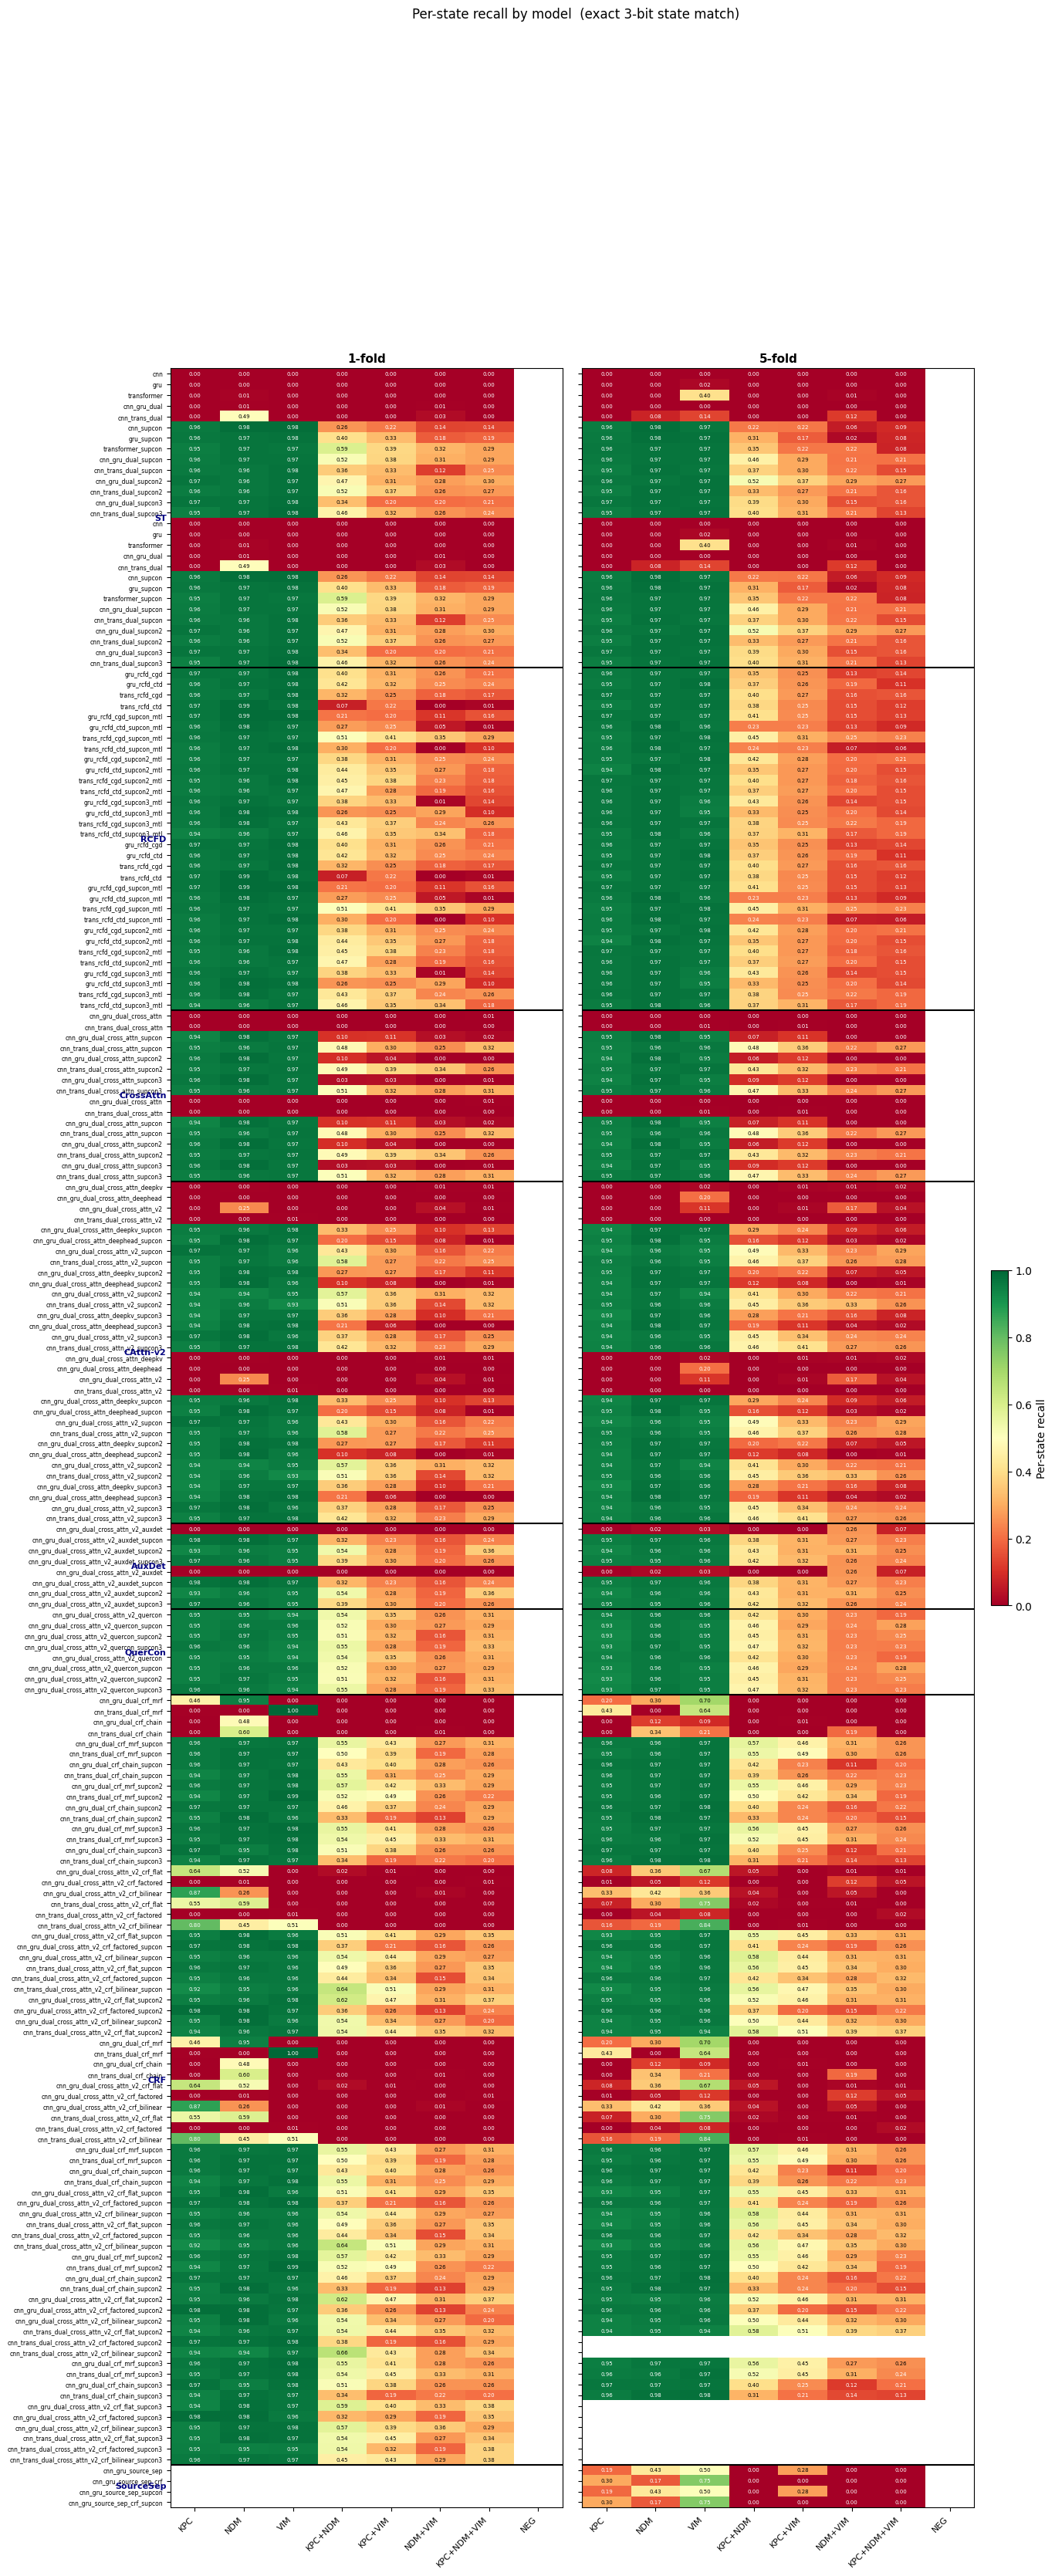

In [16]:
# Ordered model list grouped by family (used by all heatmap cells)
model_order, family_boundaries = [], []
for pair in JOBLIB_PAIRS:
    family = pair[0]
    mods = [m for m in (list(df_1fold.index) + list(df_5fold.index))
            if m not in [x for x in model_order]
            and (m in df_1fold.index and df_1fold.loc[m, 'family'] == family
                 or m in df_5fold.index and df_5fold.loc[m, 'family'] == family)]
    seen = set(model_order)
    ordered = [m for m in (list(df_5fold[df_5fold['family'] == family].index) +
                           list(df_1fold[df_1fold['family'] == family].index))
               if m not in seen]
    if not ordered:
        continue
    family_boundaries.append((len(model_order), len(model_order) + len(ordered) - 1, family))
    model_order.extend(ordered)

def build_heatmap_matrix(df):
    mat = np.full((len(model_order), N_STATES), np.nan)
    for i, m in enumerate(model_order):
        if m not in df.index:
            continue
        for j, s in enumerate(DISP_ORDER):
            mat[i, j] = df.loc[m, f's{s}_recall']
    return mat

fig, axes = plt.subplots(1, 2, figsize=(14, max(8, len(model_order) * 0.18)),
                         sharey=True, gridspec_kw={'wspace': 0.05})

for ax, df_x, fold_label in [(axes[0], df_1fold, '1-fold'),
                              (axes[1], df_5fold, '5-fold')]:
    mat = build_heatmap_matrix(df_x)
    im  = ax.imshow(mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(N_STATES))
    ax.set_xticklabels(DISP_LABELS, rotation=45, ha='right', fontsize=8)
    ax.set_title(fold_label, fontsize=11, fontweight='bold')
    for r in range(len(model_order)):
        for c in range(N_STATES):
            v = mat[r, c]
            if not np.isnan(v):
                ax.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=5,
                        color='black' if 0.25 < v < 0.75 else 'white')
    for start, end, _ in family_boundaries:
        if start > 0:
            ax.axhline(start - 0.5, color='black', lw=1.5)

axes[0].set_yticks(range(len(model_order)))
axes[0].set_yticklabels(model_order, fontsize=5.5)
for start, end, fam in family_boundaries:
    axes[0].annotate(fam, xy=(-0.01, (start + end) / 2),
                     xycoords=('axes fraction', 'data'),
                     fontsize=8, fontweight='bold', color='navy', ha='right', va='center')

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='Per-state recall')
fig.suptitle('Per-state recall by model  (exact 3-bit state match)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

Cells only in 5-fold (no 1-fold counterpart): 28


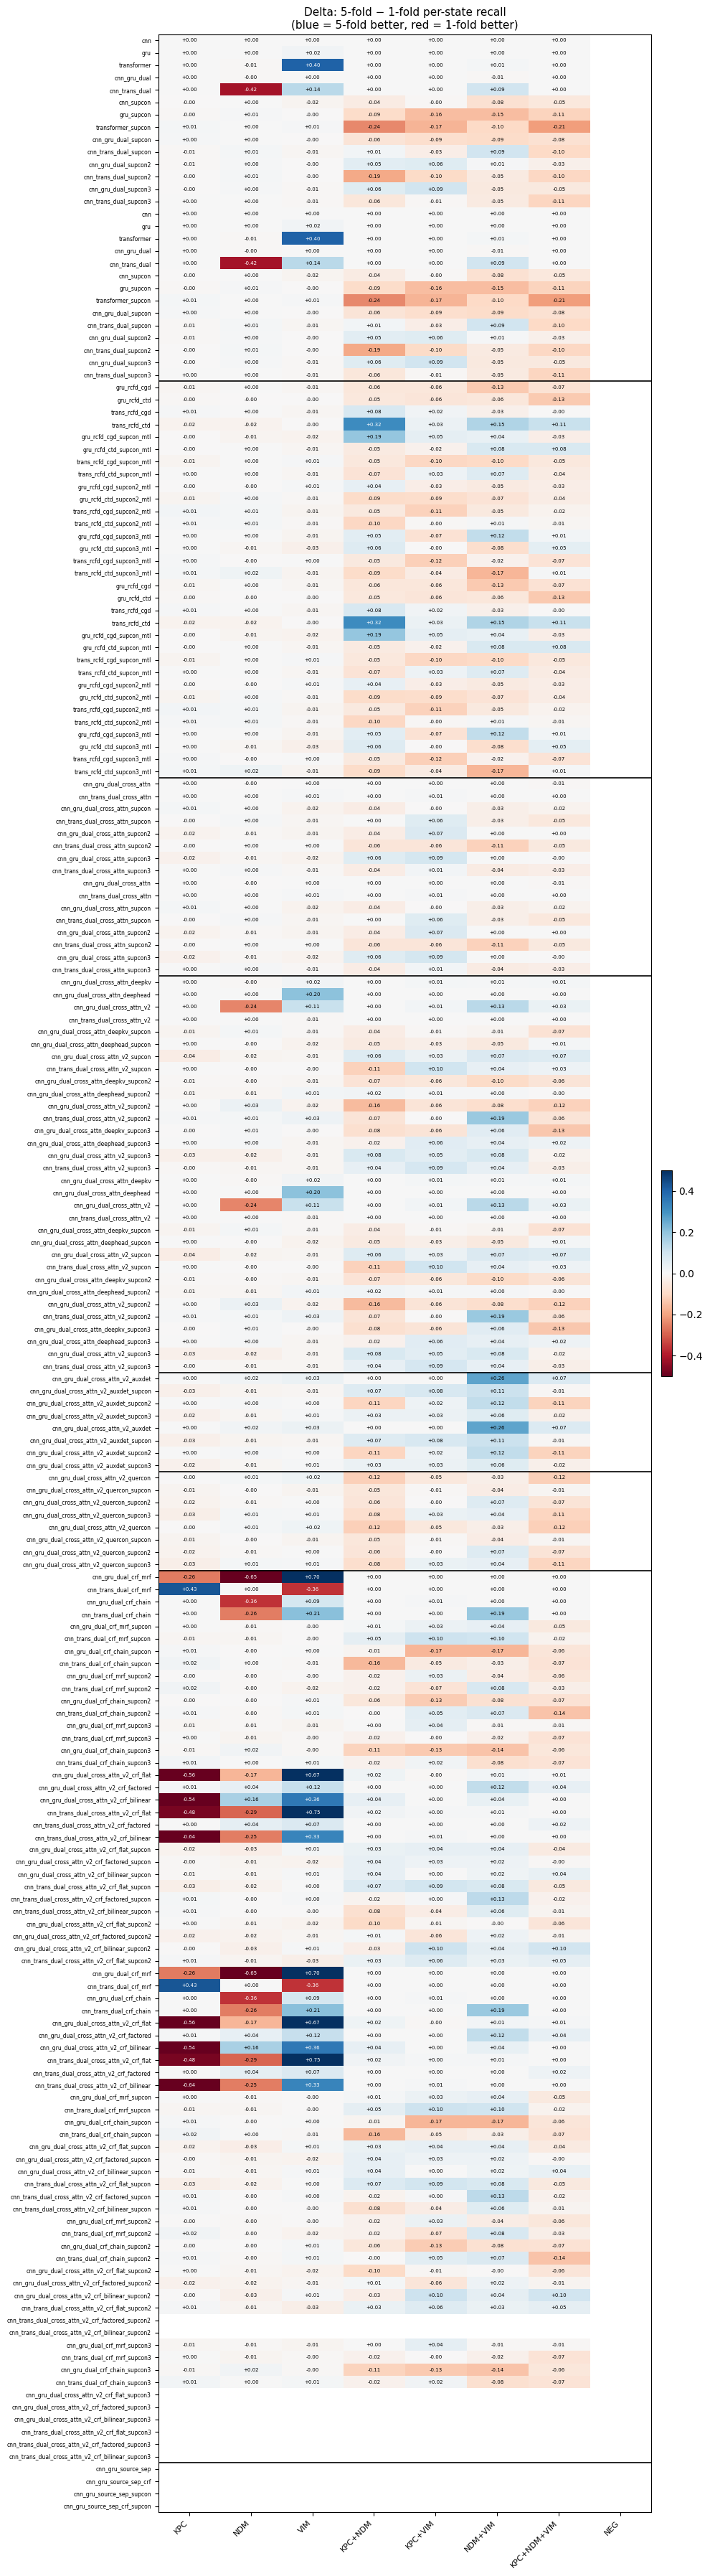

In [17]:
mat1  = build_heatmap_matrix(df_1fold)
mat5  = build_heatmap_matrix(df_5fold)
delta = mat5 - mat1

print(f"Cells only in 5-fold (no 1-fold counterpart): {int(np.sum(np.isnan(mat1) & ~np.isnan(mat5)))}")

fig, ax = plt.subplots(figsize=(10, max(8, len(model_order) * 0.18)))
im = ax.imshow(delta, cmap='RdBu', vmin=-0.5, vmax=0.5, aspect='auto')
ax.set_xticks(range(N_STATES))
ax.set_xticklabels(DISP_LABELS, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(model_order)))
ax.set_yticklabels(model_order, fontsize=5.5)
ax.set_title('Delta: 5-fold − 1-fold per-state recall\n(blue = 5-fold better, red = 1-fold better)',
             fontsize=11)
for r in range(len(model_order)):
    for c in range(N_STATES):
        v = delta[r, c]
        if not np.isnan(v):
            ax.text(c, r, f'{v:+.2f}', ha='center', va='center', fontsize=5,
                    color='black' if abs(v) < 0.3 else 'white')
for start, _, _ in family_boundaries:
    if start > 0:
        ax.axhline(start - 0.5, color='black', lw=1.2)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
plt.tight_layout()
plt.show()

In [18]:
auc_cols   = [f'auc_{n}' for n in TARGET_NAMES]
common     = df_1fold.index.intersection(df_5fold.index)
auc_merged = pd.concat(
    [df_1fold.loc[common, ['family'] + auc_cols].rename(columns={c: f'1F_{c}' for c in auc_cols}),
     df_5fold.loc[common,               auc_cols ].rename(columns={c: f'5F_{c}' for c in auc_cols})],
    axis=1
)
# interleave columns: 1F_KPC, 5F_KPC, 1F_NDM, 5F_NDM, …
col_order  = ['family'] + [f'{fs}_{c}' for c in auc_cols for fs in ('1F', '5F')]
auc_merged = auc_merged[col_order]

display(auc_merged.style
    .background_gradient(cmap='RdYlGn', vmin=0.5, vmax=1.0,
                         subset=[c for c in auc_merged.columns if c != 'family'])
    .format('{:.3f}', na_rep='-',
            subset=[c for c in auc_merged.columns if c != 'family'])
    .set_caption('Per-label AUC  —  1-fold (1F) vs 5-fold (5F)'))

,family,1F_auc_KPC,5F_auc_KPC,1F_auc_NDM,5F_auc_NDM,1F_auc_VIM,5F_auc_VIM
model,,,,,,,
cnn,ST,0.532,0.523,0.754,0.598,0.726,0.594
gru,ST,0.561,0.520,0.683,0.556,0.719,0.615
transformer,ST,0.505,0.512,0.701,0.676,0.747,0.574
cnn_gru_dual,ST,0.534,0.525,0.690,0.681,0.644,0.646
cnn_trans_dual,ST,0.488,0.536,0.718,0.701,0.588,0.640
cnn_supcon,ST,0.976,0.965,0.971,0.964,0.966,0.962
gru_supcon,ST,0.978,0.966,0.975,0.964,0.968,0.963
transformer_supcon,ST,0.980,0.966,0.978,0.963,0.970,0.964
cnn_gru_dual_supcon,ST,0.979,0.975,0.979,0.973,0.971,0.969


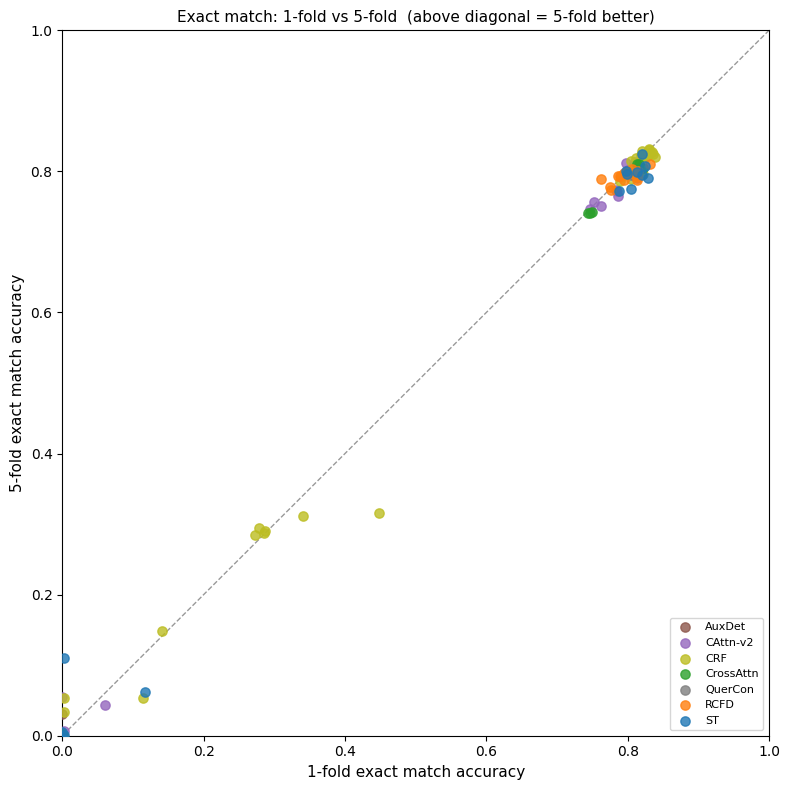

In [19]:
common = df_1fold.index.intersection(df_5fold.index)
merged = df_1fold.loc[common, ['family', 'exact_match']].rename(
             columns={'exact_match': 'em_1fold'}).join(
         df_5fold.loc[common,        'exact_match'].rename('em_5fold'))

family_list = [p[0] for p in JOBLIB_PAIRS]
colors      = plt.cm.tab10(np.linspace(0, 1, len(family_list)))
cmap        = dict(zip(family_list, colors))

fig, ax = plt.subplots(figsize=(8, 8))
for fam, grp in merged.groupby('family'):
    ax.scatter(grp['em_1fold'], grp['em_5fold'],
               c=[cmap.get(fam, 'grey')], s=45, alpha=0.8, zorder=3, label=fam)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax.set_xlabel('1-fold exact match accuracy', fontsize=11)
ax.set_ylabel('5-fold exact match accuracy', fontsize=11)
ax.set_title('Exact match: 1-fold vs 5-fold  (above diagonal = 5-fold better)', fontsize=11)
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

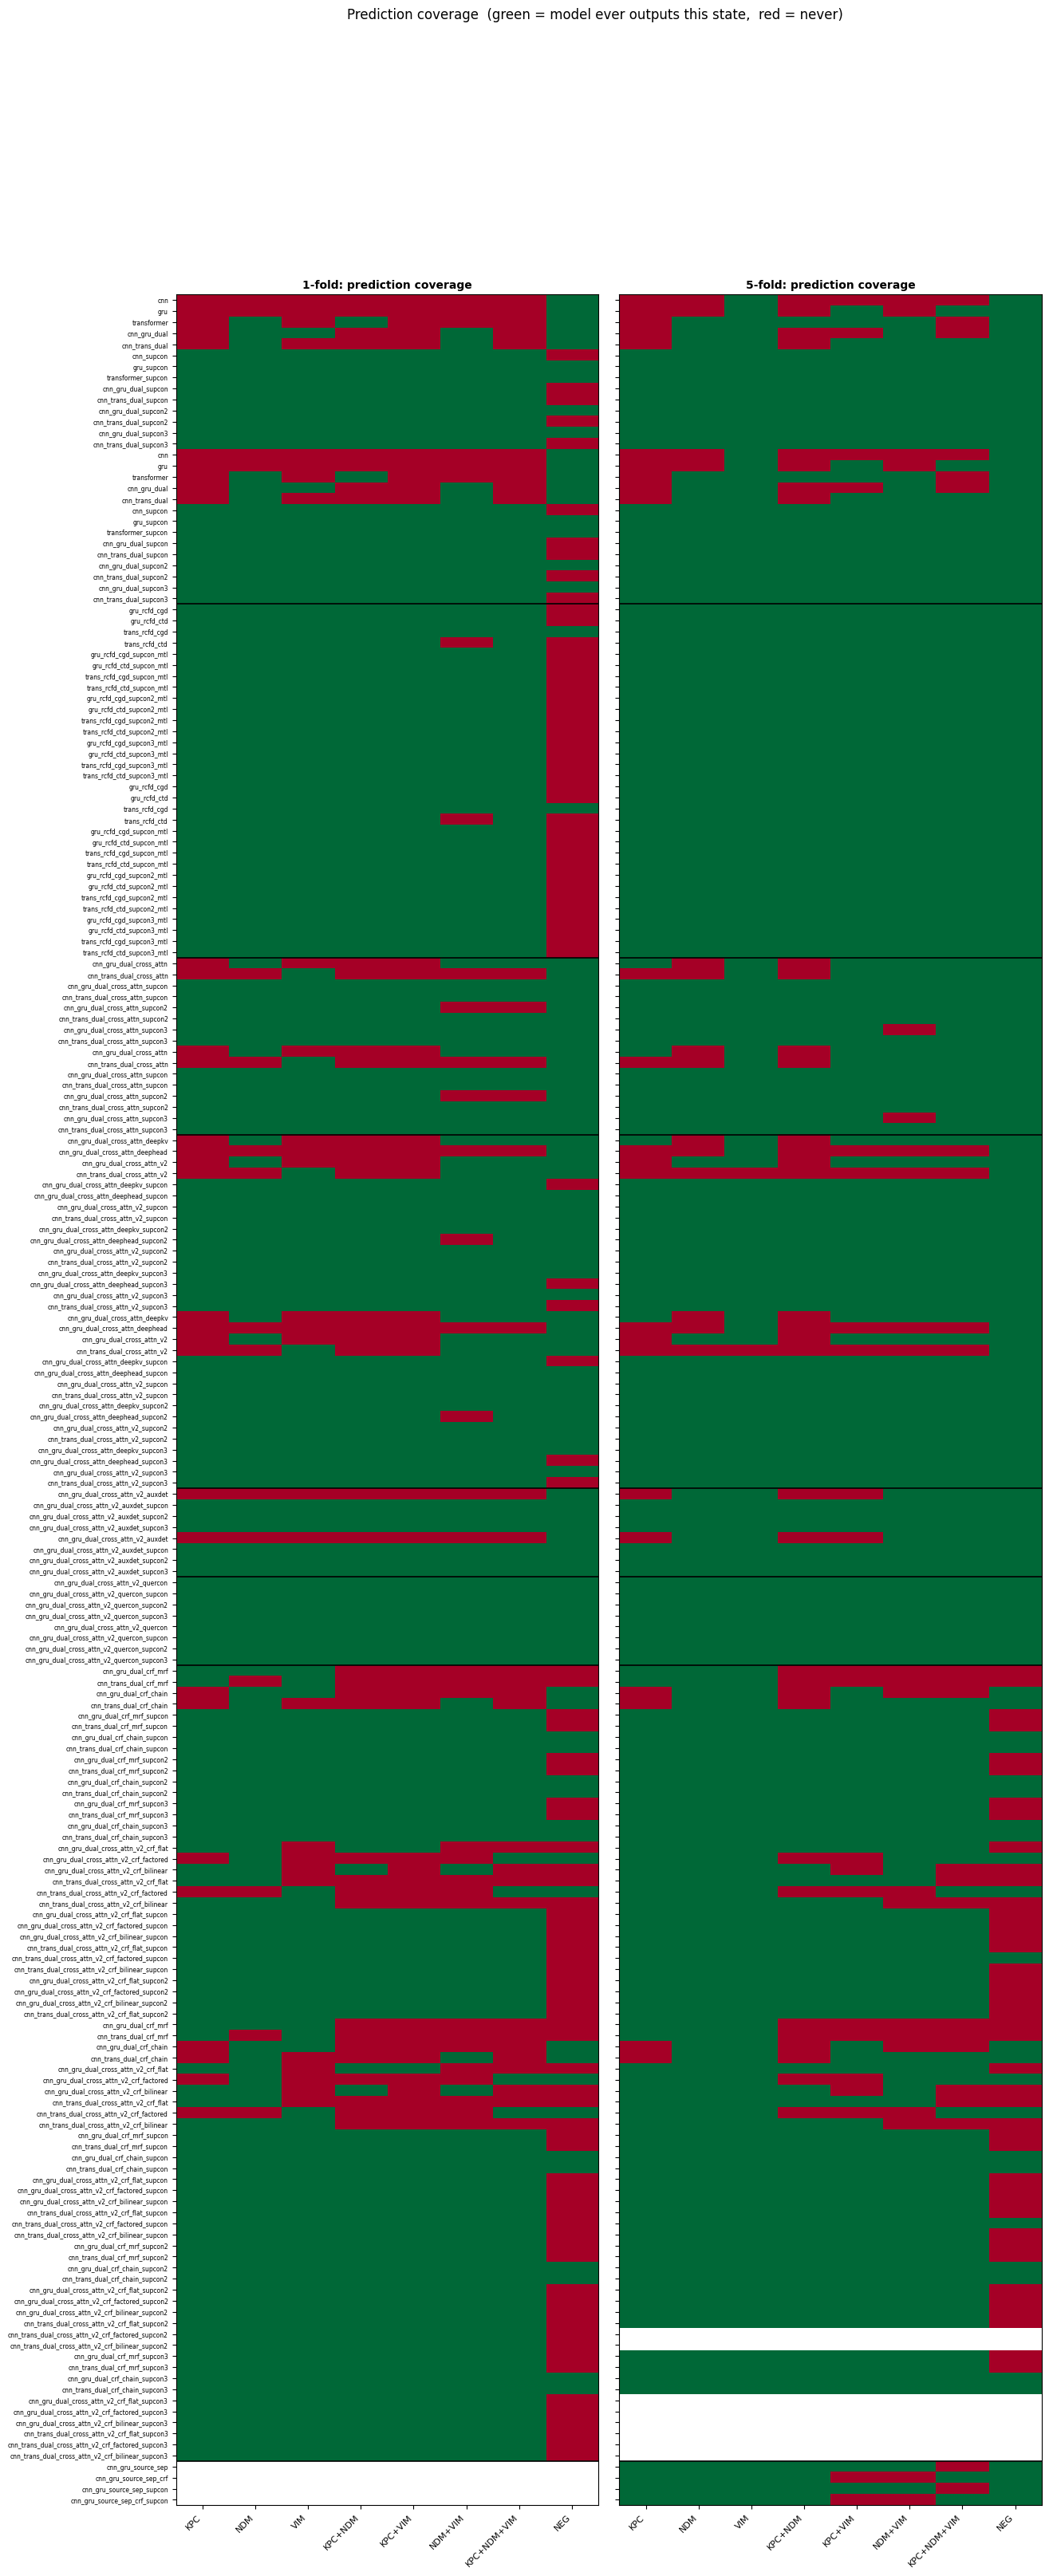

In [20]:
# Which states does each model ever output?  (from predicted_states column)
def build_coverage_matrix(df):
    mat = np.full((len(model_order), N_STATES), np.nan)
    for i, m in enumerate(model_order):
        if m not in df.index:
            continue
        ps = df.loc[m, 'predicted_states']
        for j, s in enumerate(DISP_ORDER):
            mat[i, j] = float(s in ps)
    return mat

fig, axes = plt.subplots(1, 2, figsize=(14, max(8, len(model_order) * 0.18)),
                         sharey=True, gridspec_kw={'wspace': 0.05})
for ax, df_x, fold_label in [(axes[0], df_1fold, '1-fold'),
                              (axes[1], df_5fold, '5-fold')]:
    mat = build_coverage_matrix(df_x)
    ax.imshow(mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(N_STATES))
    ax.set_xticklabels(DISP_LABELS, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{fold_label}: prediction coverage', fontsize=10, fontweight='bold')
    for start, _, _ in family_boundaries:
        if start > 0:
            ax.axhline(start - 0.5, color='black', lw=1.2)

axes[0].set_yticks(range(len(model_order)))
axes[0].set_yticklabels(model_order, fontsize=5.5)
fig.suptitle('Prediction coverage  (green = model ever outputs this state,  red = never)', fontsize=12)
plt.tight_layout()
plt.show()

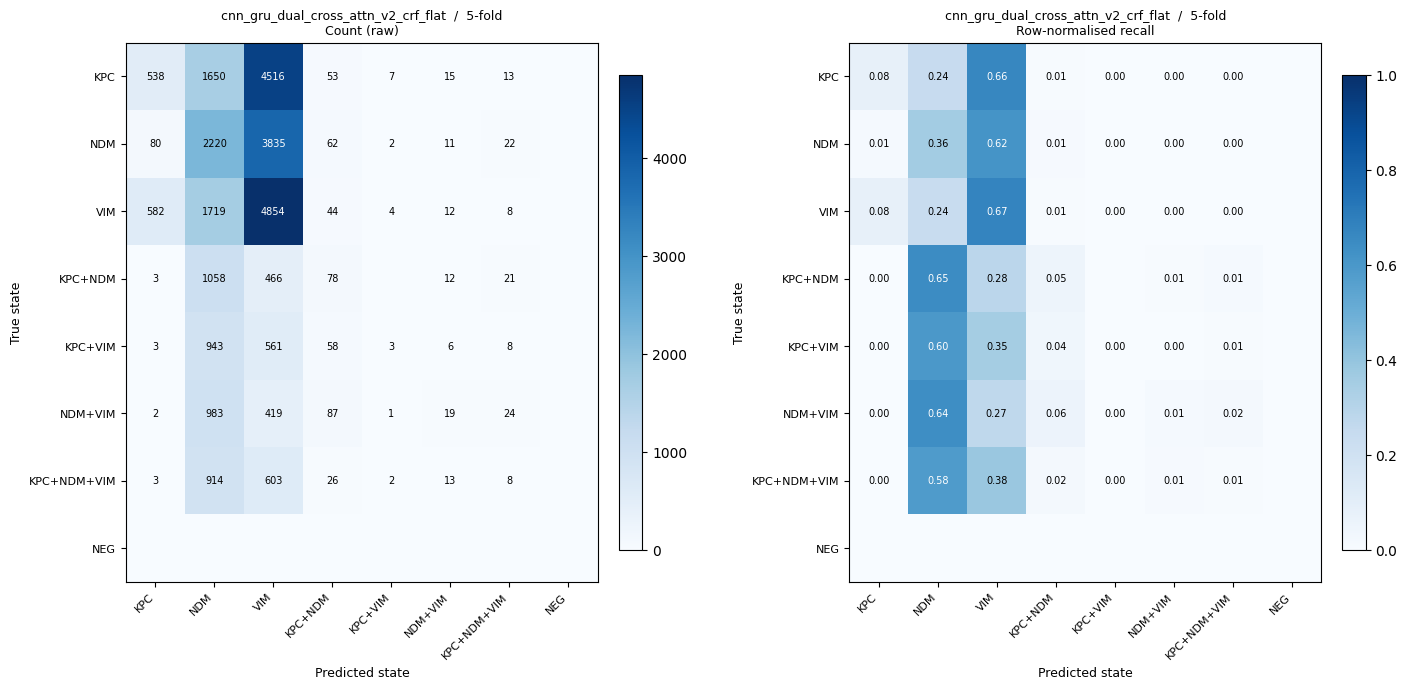


True state               N   Recall  Top misprediction
  KPC                 6792    0.079  → VIM
  NDM                 6232    0.356  → VIM
  VIM                 7223    0.672  → NDM
  KPC+NDM             1638    0.048  → NDM
  KPC+VIM             1582    0.002  → NDM
  NDM+VIM             1535    0.012  → NDM
  KPC+NDM+VIM         1569    0.005  → NDM
  NEG                    0    0.000  → -


In [21]:
# ── Confusion flow: where does each true state get mispredicted?
# Change INSPECT_MODEL and INSPECT_FOLD to inspect any model.
INSPECT_MODEL = 'cnn_gru_dual_cross_attn_v2_crf_flat'
INSPECT_FOLD  = '5-fold'   # '1-fold' or '5-fold'

preds_dict = preds_5fold if INSPECT_FOLD == '5-fold' else preds_1fold

if INSPECT_MODEL not in preds_dict:
    print(f"'{INSPECT_MODEL}' not found in {INSPECT_FOLD} predictions.")
    print("Available models (first 10):", list(preds_dict.keys())[:10])
else:
    p    = preds_dict[INSPECT_MODEL]
    true_s = state_idx(p['y_true'])
    pred_s = state_idx(p['y_pred'])

    cm = np.array([[(((true_s == t) & (pred_s == pp)).sum())
                    for pp in range(N_STATES)]
                   for t  in range(N_STATES)], dtype=int)
    row_sums  = cm.sum(axis=1, keepdims=True)
    cm_norm   = np.where(row_sums > 0, cm / row_sums, 0.0)
    cm_d      = cm[np.ix_(DISP_ORDER, DISP_ORDER)]
    cm_norm_d = cm_norm[np.ix_(DISP_ORDER, DISP_ORDER)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'wspace': 0.4})
    for ax, mat, title, fmt, vmax in [
        (axes[0], cm_d,      'Count (raw)',           'd',   cm_d.max()),
        (axes[1], cm_norm_d, 'Row-normalised recall', '.2f', 1.0),
    ]:
        im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=vmax, aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(N_STATES)); ax.set_xticklabels(DISP_LABELS, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(N_STATES)); ax.set_yticklabels(DISP_LABELS, fontsize=8)
        ax.set_xlabel('Predicted state', fontsize=9); ax.set_ylabel('True state', fontsize=9)
        ax.set_title(f'{INSPECT_MODEL}  /  {INSPECT_FOLD}\n{title}', fontsize=9)
        thresh = vmax * 0.5
        for r in range(N_STATES):
            for c in range(N_STATES):
                v = mat[r, c]
                if v > 0:
                    txt = f'{int(v)}' if fmt == 'd' else f'{v:.2f}'
                    ax.text(c, r, txt, ha='center', va='center', fontsize=7,
                            color='white' if v > thresh else 'black')
    plt.tight_layout(); plt.show()

    print(f"\n{'True state':18s}  {'N':>6}  {'Recall':>7}  {'Top misprediction'}")
    for si, s in enumerate(DISP_ORDER):
        n   = cm_d[si, :].sum()
        rec = cm_norm_d[si, si]
        wrong = cm_norm_d[si].copy(); wrong[si] = 0
        top   = DISP_LABELS[wrong.argmax()] if wrong.max() > 0 else '-'
        print(f"  {DISP_LABELS[si]:16s}  {n:6d}  {rec:7.3f}  → {top}")

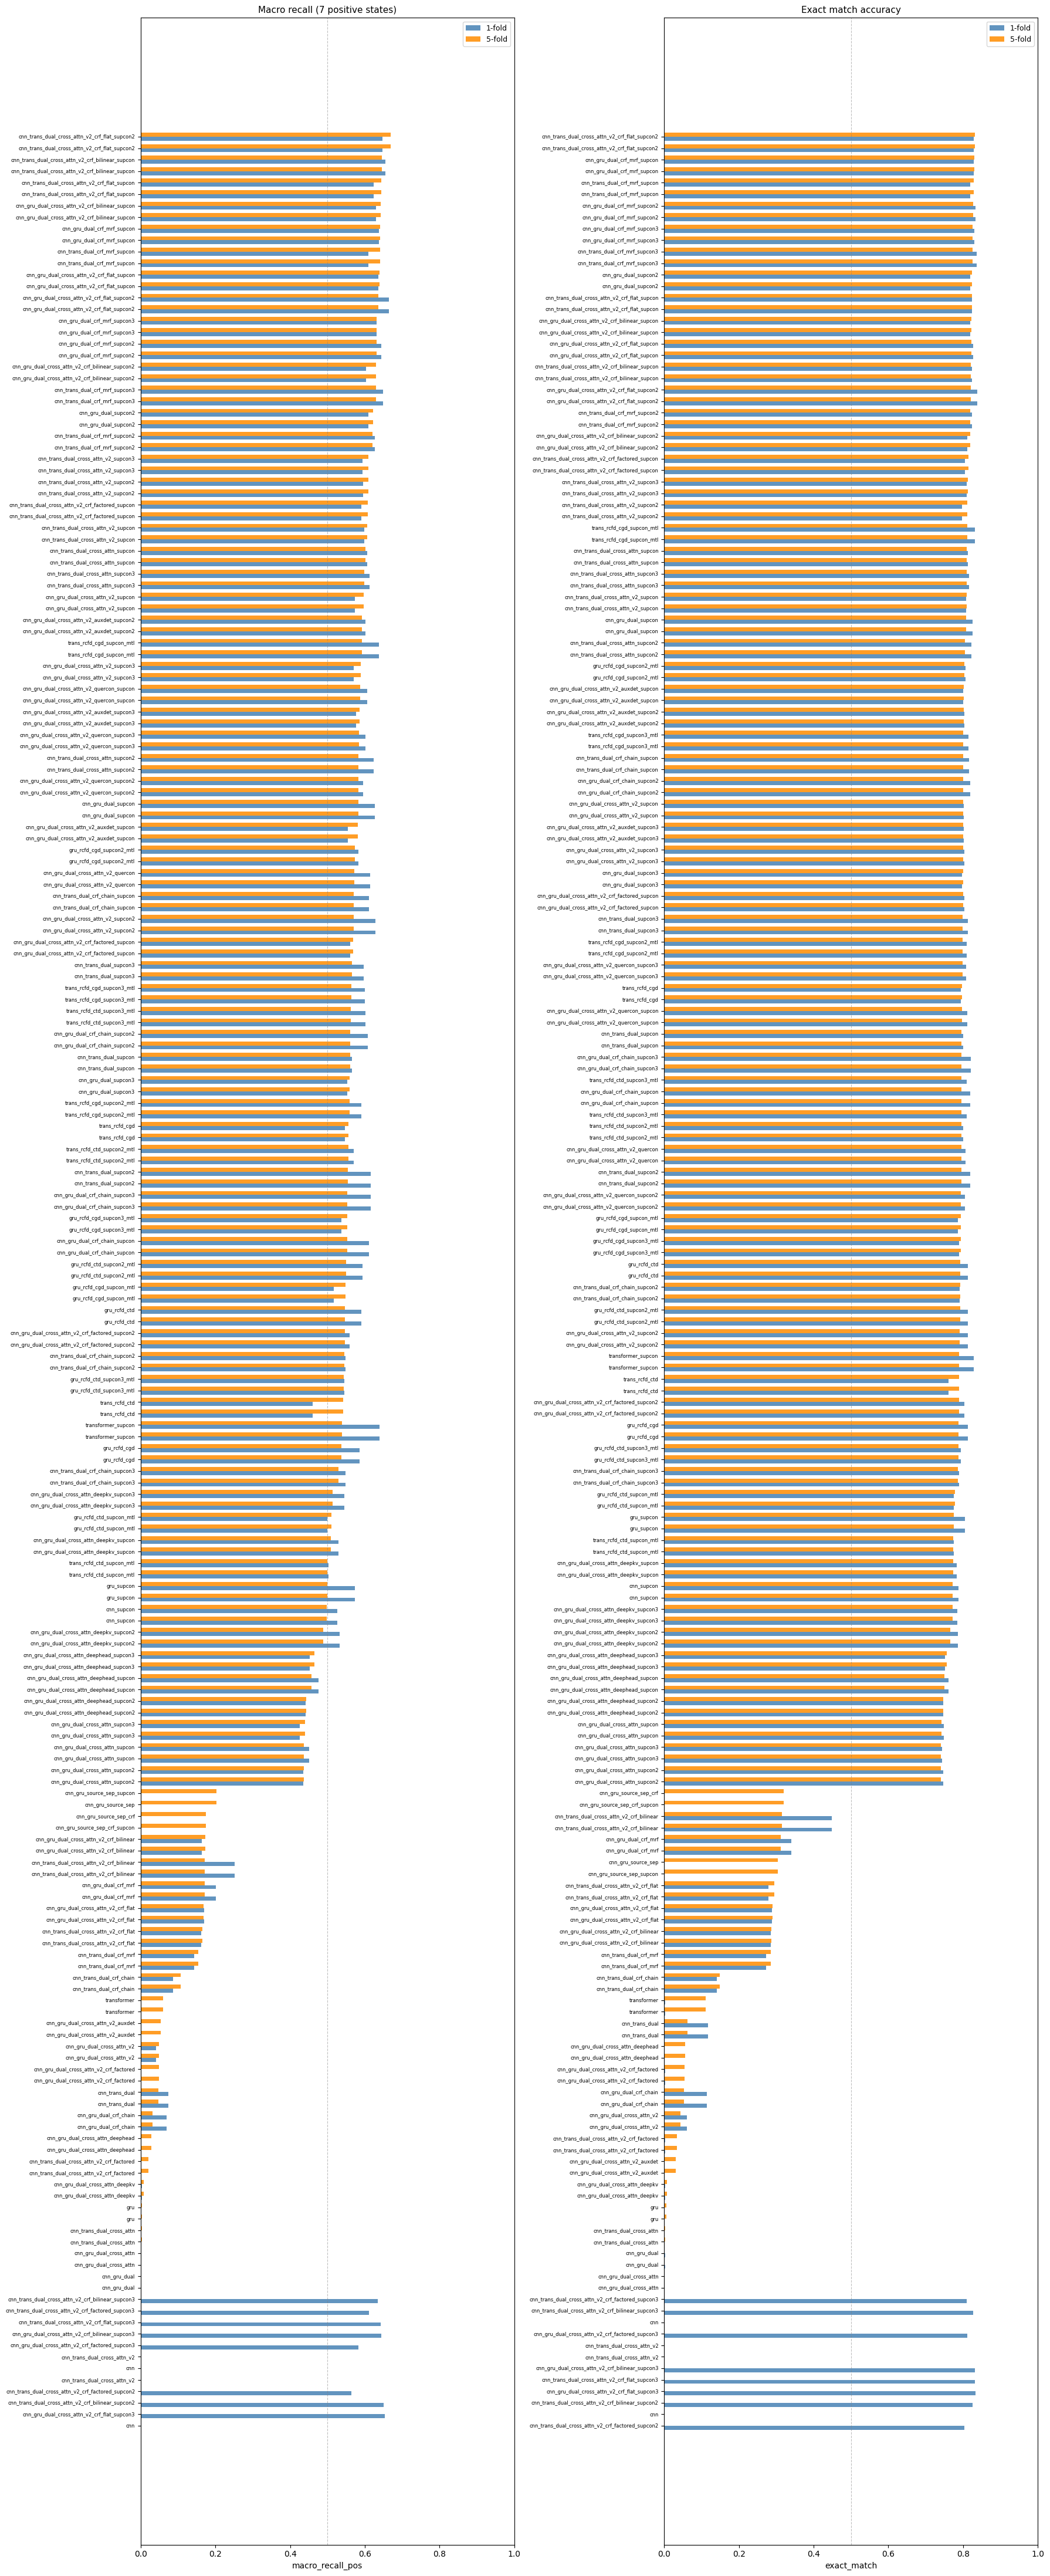


Top 10 by 5-fold macro recall (positive states):
                                                 family  macro_recall_pos  exact_match
model                                                                                 
cnn_trans_dual_cross_attn_v2_crf_flat_supcon2       CRF          0.668716     0.831282
cnn_trans_dual_cross_attn_v2_crf_bilinear_supcon    CRF          0.645230     0.821309
cnn_trans_dual_cross_attn_v2_crf_flat_supcon        CRF          0.644047     0.823341
cnn_gru_dual_cross_attn_v2_crf_bilinear_supcon      CRF          0.642813     0.822852
cnn_gru_dual_crf_mrf_supcon                         CRF          0.641728     0.830266
cnn_trans_dual_crf_mrf_supcon                       CRF          0.640246     0.828874
cnn_gru_dual_cross_attn_v2_crf_flat_supcon          CRF          0.640021     0.821911
cnn_gru_dual_cross_attn_v2_crf_flat_supcon2         CRF          0.636299     0.820782
cnn_gru_dual_crf_mrf_supcon3                        CRF          0.632372     0.

In [22]:
# Rank by macro recall over 7 positive states (state 0 = NEG excluded)
common = df_5fold.index  # rank on 5-fold; 1-fold shown alongside

fig, axes = plt.subplots(1, 2, figsize=(18, max(10, len(model_order) * 0.22)))
for ax, metric, title in [
    (axes[0], 'macro_recall_pos', 'Macro recall (7 positive states)'),
    (axes[1], 'exact_match',      'Exact match accuracy'),
]:
    vals_5 = df_5fold[metric].reindex(model_order)
    vals_1 = df_1fold[metric].reindex(model_order) if metric in df_1fold.columns else pd.Series(dtype=float)
    sort_idx = np.argsort(vals_5.fillna(0).values)
    sorted_models = [model_order[i] for i in sort_idx]
    y  = np.arange(len(sorted_models))
    w  = 0.35
    v1 = df_1fold[metric].reindex(sorted_models)
    v5 = df_5fold[metric].reindex(sorted_models)
    ax.barh(y - w/2, v1, height=w, label='1-fold', color='steelblue', alpha=0.85)
    ax.barh(y + w/2, v5, height=w, label='5-fold', color='darkorange', alpha=0.85)
    ax.set_yticks(y); ax.set_yticklabels(sorted_models, fontsize=6)
    ax.set_xlabel(metric, fontsize=10); ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9); ax.set_xlim(0, 1)
    ax.axvline(0.5, color='grey', lw=0.8, ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

print("\nTop 10 by 5-fold macro recall (positive states):")
top10 = df_5fold[['family', 'macro_recall_pos', 'exact_match']]        .sort_values('macro_recall_pos', ascending=False).head(10)
print(top10.to_string())